[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_03/MFM_ch3_seminar/MFM_ch3_seminar.ipynb)

# Modelling Financial Markets — Seminar 3: Factor Models and Asset Pricing

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza — Bucharest University of Economic Studies.*

- **Part A**: numerical check of the eight derivations.
- **Part B**: estimation and inference on US and Romanian data.
- **Part C**: open questions and AI critique: C1, factor premia on the Bucharest Stock Exchange; C2, critique of an AI momentum backtest.
- **[Solved]** problems are fully worked out (code and output); **[Proposed]** problems have an empty cell for you: their solutions are discussed in the seminar.
- Worked example to follow: A1 for A2; A3 for A4; A7 for A6; B3 for A8; B1 for B4, B6, B10; B2 for B5, B9, B11; A5 for B7; B3 for B8.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> Quantlet `MFM_ch3_seminar`: student version of the Seminar 3 notebook. Solved exercises (A1, A1 Extended, A3, A5, A7, B1, B2, B3) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B4, B5, B6, B7, B8, B9, B10, B11, C1, C2, C3) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

In [ ]:
import os
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # from Dec 1998
SECTORS_ALL = SECTORS + ['XLRE', 'XLC']                                           # XLRE 2015, XLC 2018
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary', 'XLRE': 'Real estate', 'XLC': 'Communication'}
FACTOR_ETFS = ['MTUM', 'VLUE', 'QUAL', 'USMV', 'IWM', 'IWD', 'IWF']
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'FP', 'SNG', 'H2O', 'SNN', 'EL', 'DIGI', 'TEL']
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'FP': 'Fondul Proprietatea', 'SNG': 'Romgaz', 'H2O': 'Hidroelectrica', 'SNN': 'Nuclearelectrica',
             'EL': 'Electrica', 'DIGI': 'Digi', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Daily prices of one asset from the course data."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Price used: adjusted close for ETFs and stocks, close for indices."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Prices aligned on the common days (multi-asset analyses align prices before taking returns)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Log returns of an already aligned table (common days)."""
    return np.log(p).diff().dropna()


# =============================================================================
# KENNETH FRENCH DATA LIBRARY
# =============================================================================
FILES = {
    ('ff3', 'M'): 'F-F_Research_Data_Factors_CSV.zip',
    ('ff3', 'D'): 'F-F_Research_Data_Factors_daily_CSV.zip',
    ('ff5', 'M'): 'F-F_Research_Data_5_Factors_2x3_CSV.zip',
    ('ff5', 'D'): 'F-F_Research_Data_5_Factors_2x3_daily_CSV.zip',
    ('mom', 'M'): 'F-F_Momentum_Factor_CSV.zip',
    ('mom', 'D'): 'F-F_Momentum_Factor_daily_CSV.zip',
    ('p25', 'M'): '25_Portfolios_5x5_CSV.zip',
    ('ind10', 'M'): '10_Industry_Portfolios_CSV.zip',
    ('ind30', 'M'): '30_Industry_Portfolios_CSV.zip',
    ('p100', 'M'): '100_Portfolios_10x10_CSV.zip',
    # univariate sorts (first table: value-weighted), Jensen-Kelly-Pedersen case study
    ('ME', 'M'): 'Portfolios_Formed_on_ME_CSV.zip',
    ('BE-ME', 'M'): 'Portfolios_Formed_on_BE-ME_CSV.zip',
    ('OP', 'M'): 'Portfolios_Formed_on_OP_CSV.zip',
    ('INV', 'M'): 'Portfolios_Formed_on_INV_CSV.zip',
    ('E-P', 'M'): 'Portfolios_Formed_on_E-P_CSV.zip',
    ('CF-P', 'M'): 'Portfolios_Formed_on_CF-P_CSV.zip',
    ('D-P', 'M'): 'Portfolios_Formed_on_D-P_CSV.zip',
    ('AC', 'M'): 'Portfolios_Formed_on_AC_CSV.zip',
    ('NI', 'M'): 'Portfolios_Formed_on_NI_CSV.zip',
    ('BETA', 'M'): 'Portfolios_Formed_on_BETA_CSV.zip',
    ('VAR', 'M'): 'Portfolios_Formed_on_VAR_CSV.zip',
    ('RESVAR', 'M'): 'Portfolios_Formed_on_RESVAR_CSV.zip',
    ('PRIOR_12_2', 'M'): '10_Portfolios_Prior_12_2_CSV.zip',
    ('PRIOR_1_0', 'M'): '10_Portfolios_Prior_1_0_CSV.zip',
    ('PRIOR_60_13', 'M'): '10_Portfolios_Prior_60_13_CSV.zip',
}


def _parse_first_table(text, date_len):
    """First table of a French data set: header ',col1,col2...', then rows YYYYMM(DD),values."""
    lines = text.splitlines()
    i = next(k for k, l in enumerate(lines) if l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != date_len or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    fmt = '%Y%m' if date_len == 6 else '%Y%m%d'
    df['date'] = pd.to_datetime(df['date'], format=fmt)
    if date_len == 6:
        df['date'] = df['date'] + pd.offsets.MonthEnd(0)
    df = df.set_index('date')
    return df.replace([-99.99, -999.0], np.nan) / 100.0          # percent -> decimal


def french(name='ff5', freq='M'):
    """Fama-French factors / momentum / portfolios, in decimals (0.01 = 1%)."""
    key = (name, freq)
    if key in _CACHE:
        return _CACHE[key]
    url = FRENCH + FILES[key]
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    df = _parse_first_table(text, 6 if freq == 'M' else 8)
    df.columns = [c.replace('Mom', 'MOM').strip() for c in df.columns]
    _CACHE[key] = df
    return df


def factors(freq='M'):
    """Mkt-RF, SMB, HML, RMW, CMA, RF, MOM and SMB_FF3 over the common period.

    The five-factor SMB (sorts on B/M, profitability and investment) enters FF5;
    SMB_FF3 is the published three-factor SMB (2x3 sorts on size and B/M),
    used in FF3 and Carhart. HML, Mkt-RF and RF are the same in the two data sets.
    """
    f3 = french('ff3', freq)[['SMB']].rename(columns={'SMB': 'SMB_FF3'})
    return pd.concat([french('ff5', freq), french('mom', freq), f3], axis=1).dropna()


# =============================================================================
# REGRESSIONS
# =============================================================================
def ols_hac(y, X, lags=None, const=True):
    """OLS with Newey-West (Bartlett) standard errors. Returns (coef, se, t, resid, r2)."""
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    if const:
        X = np.column_stack([np.ones(len(y)), X])
    n, k = X.shape
    if lags is None:
        lags = int(np.floor(4 * (n / 100) ** (2 / 9)))
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    e = y - X @ b
    u = X * e[:, None]
    S = u.T @ u
    for l in range(1, lags + 1):
        w = 1 - l / (lags + 1)
        G = u[l:].T @ u[:-l]
        S += w * (G + G.T)
    V = XtX_inv @ S @ XtX_inv
    se = np.sqrt(np.diag(V))
    r2 = 1 - e.var() / y.var()
    return b, se, b / se, e, r2


def grs_test(excess, market_excess):
    """Gibbons-Ross-Shanken (1989) test of alpha = 0 on N assets, one factor.

    Sigma and the factor variance are maximum-likelihood estimators (division by T);
    under i.i.d. Normal residuals, W ~ F(N, T - N - 1) exactly.
    """
    from scipy import stats
    R = np.asarray(excess, float)
    f = np.asarray(market_excess, float)
    T, N = R.shape
    X = np.column_stack([np.ones(T), f])
    B = np.linalg.lstsq(X, R, rcond=None)[0]
    alpha = B[0]
    E = R - X @ B
    Sigma = E.T @ E / T
    mu, s2 = f.mean(), f.var(ddof=0)
    stat = (T - N - 1) / N * (alpha @ np.linalg.solve(Sigma, alpha)) / (1 + mu ** 2 / s2)
    p = 1 - stats.f.cdf(stat, N, T - N - 1)
    return stat, p, alpha, B[1]

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']

# models: FF3 and Carhart use the published three-factor SMB; FF5 uses the five-factor SMB
FF3 = ['Mkt-RF', 'SMB_FF3', 'HML']
CARHART = FF3 + ['MOM']
FF5 = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
FF6 = FF5 + ['MOM']

SEED = 42
MAX_ABS_RET = 0.5        # data-error threshold for the BVB series (daily log return)
END = '2026-07-31'       # last month of the monthly sample used in the chapter (T = 757 months from July 1963)


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def monthly_excess(symbols, start='1999-01-01'):
    """Monthly simple excess returns over RF (one-month T-bill), on the common months."""
    p = prices(symbols).resample('ME').last()
    r = p.pct_change().dropna()
    F = factors('M')
    idx = r.index.intersection(F.index)
    r = r.loc[idx].loc[start:END]
    F = F.loc[r.index]
    return r.sub(F['RF'], axis=0), F


def daily_excess_one(symbol, start=None):
    """Daily excess return of a single asset, on the factor calendar.

    Only days with a price on the previous trading day are kept
    (otherwise the return would span several days and the factors only one).
    """
    s = price(symbol)
    F = factors('D').loc[:END]                         # same sample end as the monthly data
    s = s.loc[s.index.isin(F.index)]
    cal = pd.Series(np.arange(len(F)), index=F.index)
    pos = cal.loc[s.index].values
    r = s.pct_change()
    consecutive = np.r_[False, np.diff(pos) == 1]
    r = r[consecutive].dropna()
    if start:
        r = r.loc[start:]
    Fx = F.loc[r.index]
    return (r - Fx['RF']).rename(symbol), Fx


def daily_excess(symbols, start=None):
    """Compatibility: dictionary {symbol: (excess, factors)} on each asset's calendar."""
    return {s: daily_excess_one(s, start) for s in symbols}


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

In [ ]:
def block_bootstrap_alpha(y, X, B=2000, block=20, periods=252, seed=SEED, draws=False):
    """Moving-block bootstrap (Kunsch) for the annualised alpha of an OLS regression.

    The pairs (y, X) are resampled together (blocks of whole rows). draws=True also returns the draws.
    """
    rng = np.random.default_rng(seed)
    y, X = np.asarray(y), np.asarray(X)
    n = len(y)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    Z = np.column_stack([np.ones(n), X])
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)          # the last valid block starts at n - block
        idx = (starts[:, None] + np.arange(block)).ravel()[:n]
        coef = np.linalg.lstsq(Z[idx], y[idx], rcond=None)[0]
        out[b] = coef[0] * periods
    if draws:
        return np.percentile(out, [2.5, 97.5]), out.std(), out
    return np.percentile(out, [2.5, 97.5]), out.std()


def beta_split():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S + ['SPY.US'])
    halves = [ex.loc[:'2012-12-31'], ex.loc['2013-01-01':]]
    b = []
    for h in halves:
        b.append(pd.Series({s[:-3]: ols_hac(h[s].values, h['SPY.US'].values)[0][1] for s in S}))
    se1 = pd.Series({s[:-3]: ols_hac(halves[0][s].values, halves[0]['SPY.US'].values)[1][1] for s in S})
    return b[0], b[1], se1, halves


def vasicek_prior(b, se):
    """Vasicek prior estimated from the data (empirical Bayes).

    Var_cs(beta_hat) = Var_cs(beta) + mean se^2: the dispersion of estimated betas includes estimation noise,
    so the prior variance of the true betas is Var_cs(beta_hat) - mean se(beta_hat)^2.
    """
    m = float(b.mean())
    v = float(b.var(ddof=1) - (se ** 2).mean())
    return m, max(v, 1e-6)


def sml_data(start='1963-07-31'):
    F = factors('M')
    P = french('p25', 'M').loc[start:END]
    Fx = F.loc[P.index]
    ex = P.sub(Fx['RF'], axis=0)
    mk = Fx['Mkt-RF']
    rows = []
    for c in ex.columns:
        b, se, t, e, r2 = ols_hac(ex[c].values, mk.values)
        rows.append((c, b[1], b[0] * 12, t[0], ex[c].mean() * 12))
    res = pd.DataFrame(rows, columns=['port', 'beta', 'alpha', 't_alpha', 'avg']).set_index('port')
    return res, ex, mk


def pca_sectors():
    S = [s + '.US' for s in SECTORS_ALL]
    r = log_returns(prices(S + ['SPY.US']))
    X = r[S]
    Z = (X - X.mean()) / X.std()
    C = np.corrcoef(Z.values.T)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    for k in range(vecs.shape[1]):                      # sign: positive mean loading
        if vecs[:, k].sum() < 0:
            vecs[:, k] *= -1
    pcs = Z.values @ vecs
    corr_pc1_spy = np.corrcoef(pcs[:, 0], r['SPY.US'].values)[0, 1]
    return vals, vecs, r, corr_pc1_spy


def n_factors(X, kmax):
    """Number of factors: Kaiser (eigenvalues > 1), Bai & Ng (2002) IC_p2, Ahn & Horenstein (2013) ER."""
    X = np.asarray(X, float)
    X = (X - X.mean(0)) / X.std(0)
    T, N = X.shape
    ev = np.sort(np.linalg.eigvalsh(X.T @ X / T))[::-1]         # eigenvalues of the correlation matrix
    V = [ev[k:].sum() / N for k in range(kmax + 1)]              # V(k) = (1/NT) sum of squared residuals
    pen = (N + T) / (N * T) * np.log(min(N, T))
    ic = [np.log(V[k]) + k * pen for k in range(kmax + 1)]
    er = [ev[k - 1] / ev[k] for k in range(1, kmax + 1)]
    return dict(T=T, N=N, kaiser=int((ev > 1).sum()), bai_ng=int(np.argmin(ic)),
                ahn_horenstein=int(np.argmax(er) + 1), eig=ev[:kmax + 1].round(3).tolist(),
                er=np.round(er, 2).tolist())


def eiv_attenuation():
    """Errors in variables in pass 2, conditional on the realised factor path:
    plim_N lambda_OLS / lambda_realised = Var(beta) / (Var(beta) + s2_eps / sum_t (f_t - f_bar)^2)."""
    out = {}
    res, ex, mk = sml_data()
    cases = {'25 size x B/M': (ex, mk)}
    S = [s + '.US' for s in SECTORS]
    exs, Fs = monthly_excess(S)
    cases['9 sector ETFs'] = (exs, Fs['Mkt-RF'])
    for k, (e, m) in cases.items():
        R = e.values
        f = np.asarray(m, float)
        T = len(f)
        Z = np.column_stack([np.ones(T), f])
        AB = np.linalg.lstsq(Z, R, rcond=None)[0]
        E = R - Z @ AB
        s2e = (E ** 2).sum(0) / (T - 2)
        noise = s2e.mean() / ((f - f.mean()) ** 2).sum()          # = s2_eps / (T * var_ML(f))
        vb_hat = AB[1].var(ddof=1)
        vb = vb_hat - noise
        out[k] = dict(T=T, N=R.shape[1], var_beta_hat=vb_hat, noise=noise, var_beta=vb,
                      attenuation=vb / (vb + noise), sd_beta=np.sqrt(vb_hat))
    return out


def stationary_bootstrap_idx(T, mean_block, rng):
    """Indices for the stationary bootstrap (Politis & Romano, 1994), mean block length mean_block."""
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(T)
    for t in range(1, T):
        idx[t] = rng.integers(T) if rng.random() < 1 / mean_block else (idx[t - 1] + 1) % T
    return idx

## Part A — derivations (numerical check)

### A1. The CAPM from the tangency portfolio [Solved]

- With sample moments of the 9 sector ETFs, the in-sample tangency portfolio prices every sector exactly: $\hat\mu_i = \hat\beta_i\hat\mu_m$.

In [6]:
# A1 CAPM from the tangency portfolio
ex, F = monthly_excess([s + '.US' for s in SECTORS])
mu, Sig = ex.mean().values, ex.cov().values
w = np.linalg.solve(Sig, mu); w /= w.sum()
rm = ex.values @ w
beta = np.array([np.cov(ex.values[:, i], rm)[0, 1] / rm.var(ddof=1) for i in range(ex.shape[1])])
pd.DataFrame({'mu (ann.)': 12 * mu, 'beta * mu_m (ann.)': 12 * beta * rm.mean(), 'beta': beta},
             index=SECTORS).round(4)

,mu (ann.),beta * mu_m (ann.),beta
XLB,0.0819,0.0819,0.9587
XLE,0.0963,0.0963,1.1267
XLF,0.0615,0.0615,0.7199
XLI,0.0878,0.0878,1.0272
XLK,0.1043,0.1043,1.2205
XLP,0.0528,0.0528,0.6183
XLU,0.0656,0.0656,0.7681
XLV,0.0716,0.0716,0.8373
XLY,0.0890,0.0890,1.0411


### A2. GRS equals a Sharpe-ratio gain [Proposed]

- 25 size × B/M portfolios, CAPM: $W$ from the two Sharpe ratios equals GRS.

In [ ]:
# Your code here


### A3. Vasicek as a posterior mean [Solved]

- Empirical-Bayes prior variance: $\sigma^2_\beta = \mathrm{Var}_{cs}(\hat\beta) - \overline{se^2}$.

In [8]:
# A3 Vasicek and Blume betas
b1, b2, se1, halves = beta_split()
pm, pv = vasicek_prior(b1, se1)
w = pv / (pv + se1['XLK'] ** 2)
bv = w * b1['XLK'] + (1 - w) * pm
bb = 0.33 + 0.67 * b1['XLK']
print(f"Var_cs = {b1.var(ddof=1):.3f}  mean se2 = {(se1 ** 2).mean():.4f}  prior var = {pv:.3f}  w = {w:.3f}")
print(f"Vasicek = {bv:.3f}  Blume = {bb:.3f}  realised 2013-2026 = {b2['XLK']:.3f}")

Var_cs = 0.116  mean se2 = 0.0077  prior var = 0.108  w = 0.849
Vasicek = 1.344  Blume = 1.278  realised 2013-2026 = 1.172


### A4. Blume's slope as a shrinkage weight [Proposed]

- Betas of the 9 sector ETFs in 1999–2012 ($\hat\beta_1$) and 2013–2026 ($\hat\beta_2$); assume constant true betas and independent estimation noise with common variance $se^2$.
- (a) Derive the probability limits of the OLS slope and intercept of $\hat\beta_2$ on $\hat\beta_1$; (b) show that the slope is the Vasicek weight $\sigma^2_\beta/(\sigma^2_\beta + se^2)$.
- (c) Compute the implied slope and intercept from A3 ($\sigma^2_\beta = 0.108$, $\overline{se^2} = 0.0077$, $\bar\beta = 0.949$) and compare them with the fitted line.
- (d) Interpretation: is the gap significant given the slope's standard error, and what could explain it? Model: A3.

In [ ]:
# Your code here


### A5. Ten candidate factors: Bonferroni, Holm, Benjamini–Hochberg [Solved]

In [10]:
# A5 multiple testing, step by step
p = np.array([0.001, 0.004, 0.009, 0.012, 0.021, 0.035, 0.048, 0.060, 0.20, 0.55]); m = len(p); ps = np.sort(p)
holm = 0
for k, pk in enumerate(ps):
    if pk <= 0.05 / (m - k):
        holm += 1
    else:
        break
bh = max([k + 1 for k in range(m) if ps[k] <= 0.05 * (k + 1) / m], default=0)
cm = (1 / np.arange(1, m + 1)).sum()   # Benjamini-Yekutieli: any dependence
by = max([k + 1 for k in range(m) if ps[k] <= 0.05 * (k + 1) / (m * cm)], default=0)
print('naive =', (p <= 0.05).sum(), ' Bonferroni =', (p <= 0.05 / m).sum(), ' Holm =', holm, ' BH =', bh, ' BY =', by)

naive = 7  Bonferroni = 2  Holm = 2  BH = 5  BY = 1


### A6. A useless factor in pass 2 [Proposed]

- CAPM + an independent Normal factor on the 25 portfolios: rejection rates of $\lambda_g = 0$ at 5%.

In [ ]:
# Your code here


### A7. Errors in variables in pass 2 [Solved]

In [12]:
# A7 attenuation factors
pd.DataFrame(eiv_attenuation()).T.round(4)

,T,N,var_beta_hat,noise,var_beta,attenuation,sd_beta
25 size x B/M,757.0,25.0,0.0191,0.0006,0.0184,0.9674,0.1380
9 sector ETFs,331.0,9.0,0.0925,0.0020,0.0905,0.9784,0.3041


### A8. Equicorrelated assets [Proposed]

- Correlation matrix $C = (1-\rho)I + \rho\mathbf{1}\mathbf{1}'$ with $\rho = 0.5$.
- (a) Eigenvalues and eigenvectors for $N = 3$; (b) the PC1 share $\lambda_1/N$; (c) its limit as $N \to \infty$ (check with $N = 3, 10, 100$).
- (d) Invert (c) to get the equicorrelation-equivalent correlation of a PC1 share $s$: BVB ($N = 10$, $s = 0.425$, B8) and US sectors ($N = 11$, $s = 0.660$, B3).
- (e) Interpretation: show $1 + (N-1)\bar\rho \le \lambda_1$, so these values are upper bounds on the average correlation. Model: B3.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. Beta and alpha of XLK: classical, Newey–West (lag rule) and block bootstrap [Solved]

- Interpretation: the HAC error of beta is twice the classical one; which feature of the residuals causes it?

In [14]:
# Solution
def b1_xlk():
    ex, F = monthly_excess(['XLK.US', 'SPY.US'])
    y, x = ex['XLK.US'].values, F['Mkt-RF'].values
    lags = int(np.floor(4 * (len(y) / 100) ** (2 / 9)))           # Newey-West lag rule: T = 331 -> 5
    b, se, t, e, r2 = ols_hac(y, x, lags=lags)
    Z = np.column_stack([np.ones(len(y)), x])
    s2 = e @ e / (len(y) - 2)
    se_cl = np.sqrt(np.diag(s2 * np.linalg.inv(Z.T @ Z)))
    ci, bse = block_bootstrap_alpha(y, x, block=12, periods=12)
    return dict(T=len(y), lags=lags, start=str(ex.index[0].date()), end=str(ex.index[-1].date()),
                alpha=b[0] * 12, beta=b[1], se_alpha_cl=se_cl[0] * 12, se_alpha_nw=se[0] * 12,
                se_beta_cl=se_cl[1], se_beta_nw=se[1], t_alpha_nw=t[0], r2=r2, boot_ci=ci.tolist(), boot_se=bse)


b1_xlk()

{'T': 331,
 'lags': 5,
 'start': '1999-01-31',
 'end': '2026-07-31',
 'alpha': np.float64(0.00328211178941935),
 'beta': np.float64(1.277373557864404),
 'se_alpha_cl': np.float64(0.022705609302650098),
 'se_alpha_nw': np.float64(0.02453119193015265),
 'se_beta_cl': np.float64(0.04149599890282397),
 'se_beta_nw': np.float64(0.08219343664415406),
 't_alpha_nw': np.float64(0.13379340876564275),
 'r2': np.float64(0.7422834632313802),
 'boot_ci': [-0.054587842668730485, 0.04854600818377907],
 'boot_se': np.float64(0.026115718947500043)}

### B2. GRS test on sector ETFs [Solved]

- Interpretation: why does the test reject the CAPM on the 25 portfolios but not here?

In [15]:
# Solution
def b2_grs():
    S = [s + '.US' for s in SECTORS]
    ex, F = monthly_excess(S)
    stat, p, alpha, beta = grs_test(ex.values, F['Mkt-RF'].values)
    return dict(T=len(ex), N=len(S), grs=stat, p=p, alphas=dict(zip(SECTORS, np.round(alpha * 12, 4))),
                betas=dict(zip(SECTORS, np.round(beta, 3))))


b2_grs()

{'T': 331,
 'N': 9,
 'grs': np.float64(0.5332788692814445),
 'p': np.float64(0.8500677350293644),
 'alphas': {'XLB': np.float64(-0.0008),
  'XLE': np.float64(0.0236),
  'XLF': np.float64(-0.0229),
  'XLI': np.float64(0.0052),
  'XLK': np.float64(0.0033),
  'XLP': np.float64(0.017),
  'XLU': np.float64(0.0339),
  'XLV': np.float64(0.0183),
  'XLY': np.float64(0.0043)},
 'betas': {'XLB': np.float64(1.047),
  'XLE': np.float64(0.919),
  'XLF': np.float64(1.068),
  'XLI': np.float64(1.045),
  'XLK': np.float64(1.277),
  'XLP': np.float64(0.453),
  'XLU': np.float64(0.401),
  'XLV': np.float64(0.673),
  'XLY': np.float64(1.07)}}

### B3. PCA of sector ETFs and the number of factors [Solved]

- Interpretation: would the defensive-versus-growth component earn a premium? How would you test it?

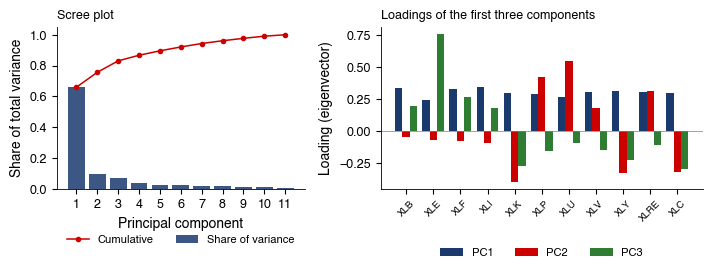

{'T': 2073,
 'share1': np.float64(0.6598485852014292),
 'share2': np.float64(0.0967418826785423),
 'cum3': np.float64(0.8308601191485488),
 'corr_pc1_spy': np.float64(0.9539639295054083),
 'n_eig_gt1': 2,
 'nfac': {'T': 2073,
  'N': 11,
  'kaiser': 2,
  'bai_ng': 5,
  'ahn_horenstein': 1,
  'eig': [7.258, 1.064, 0.817, 0.399, 0.317, 0.275],
  'er': [6.82, 1.3, 2.05, 1.26, 1.15]}}

In [16]:
# Solution
def b3_pca():
    vals, vecs, r, c1 = pca_sectors()
    share = vals / vals.sum()
    S = [s + '.US' for s in SECTORS_ALL]
    return dict(T=len(r), share1=share[0], share2=share[1], cum3=share[:3].sum(), corr_pc1_spy=c1,
                n_eig_gt1=int((vals > 1).sum()), nfac=n_factors(r[S].values, 5))


def fig_pca():
    vals, vecs, r, c1 = pca_sectors()
    share = vals / vals.sum()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={'width_ratios': [1, 1.3]})
    k = np.arange(1, len(vals) + 1)
    axes[0].bar(k, share, color=MainBlue, alpha=0.85, label='Share of variance')
    axes[0].plot(k, np.cumsum(share), color=IDAred, marker='o', ms=3, label='Cumulative')
    axes[0].set_xlabel('Principal component')
    axes[0].set_ylabel('Share of total variance')
    axes[0].set_xticks(k)
    axes[0].set_title('Scree plot', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=2, y=-0.22)
    x = np.arange(len(SECTORS_ALL))
    for j, c in enumerate([MainBlue, IDAred, Forest]):
        axes[1].bar(x + (j - 1) * 0.27, vecs[:, j], 0.27, color=c, label=f'PC{j + 1}')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xticks(x, SECTORS_ALL, rotation=45, fontsize=7)
    axes[1].set_ylabel('Loading (eigenvector)')
    axes[1].set_title('Loadings of the first three components', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=3, y=-0.3)
    plt.tight_layout()
    save_fig('ch3_pca')
    return dict(start=str(r.index[0].date()), end=str(r.index[-1].date()), T=len(r),
                share=[float(s) for s in share[:5]], cum3=float(share[:3].sum()), corr_pc1_spy=float(c1),
                load_pc2=dict(zip(SECTORS_ALL, np.round(vecs[:, 1], 3))),
                load_pc1=dict(zip(SECTORS_ALL, np.round(vecs[:, 0], 3))))


fig_pca()
b3_pca()

### B4. CAPM betas of BVB blue chips [Proposed]

- 11 blue chips vs BET, daily log returns; remove data errors; Newey–West errors, $R^2$, empirical-Bayes Vasicek and Dimson betas.
- Interpretation: how does asynchronous trading bias daily betas?

In [ ]:
# Your code here


### B5. Fama–MacBeth on sector and factor ETFs [Proposed]

- 16 ETFs, monthly 2013–2026, factors Mkt-RF, SMB, HML; Fama–MacBeth, Shanken and Kan–Robotti–Shanken errors; compare $\hat\lambda$ with the factor means.
- Interpretation: is a non-significant premium evidence that size and value are not priced?

In [ ]:
# Your code here


### B6. Do factor ETFs have alpha? [Proposed]

- MTUM and QUAL on FF5 + MOM, daily, each on its own calendar; Newey–West and block-bootstrap intervals.
- Interpretation: why must a 3-day ETF return never be regressed on a 1-day factor return?

In [ ]:
# Your code here


### B7. Multiple testing of 25 FF3 alphas [Proposed]

- Interpretation: the 25 tests are correlated; which corrections remain valid?

In [ ]:
# Your code here


### B8. PCA of BVB blue chips [Proposed]

- Interpretation: what does a weaker first factor imply for diversification within the BVB?

In [ ]:
# Your code here


### B9. A Lewellen–Nagel–Shanken check [Proposed]

- 25 size × B/M and 25 + 30 industry portfolios; CAPM, FF3, FF5; OLS and GLS $R^2$ with bootstrap intervals.
- Interpretation: does the FF3 $R^2$ survive once industries are added?

In [ ]:
# Your code here


### B10. Comparing models by Sharpe ratios [Proposed]

- Interpretation: why is a bootstrap interval useless for nested models? Which factors add no significant alpha to the others after 2000?

In [ ]:
# Your code here


### B11. GRS without normality [Proposed]

- Residual bootstrap under $H_0$ and GMM Wald tests (White, Newey–West).
- Interpretation: is the rejection of the CAPM an artefact of assuming Normal residuals?

In [ ]:
# Your code here


## Part C — open questions and AI critique

### C1. Do factor premia exist on the Bucharest Stock Exchange? [Proposed]

- Monthly momentum (12-1) and low-beta long–short portfolios, top 3 minus bottom 3 blue chips; Newey–West $t$.
- Eligibility uses only information available at the end of the previous month; the incomplete last month is dropped; a month with |r| > 50% is an unadjusted capital event (FP, September 2023): its return is unavailable, so the stock is left out of rankings whose signal contains it and out of the portfolio in that month.
- Today's blue chips are chosen retrospectively: the universe has survivorship bias.
- Size and value need fundamentals (book equity, shares outstanding), not available in the course data.

In [ ]:
# Your code here


### C2. Critique of an AI momentum backtest [Proposed]

- The prompt, the AI answer and the tasks are on the seminar slides (C2).
- Rebuild the strategy the student wanted (12-1 signal known at the end of month $t-1$, top 3 minus bottom 3, simple returns of month $t$) and compare it with the AI answer on the same months.
- Report each error you find, how you detected it, and its effect on the annual mean and volatility.

In [ ]:
# Your code here
